# Cardiovascular Disease Prediction

## 1. Project Overview

This project aims to predict the presence of cardiovascular disease in patients using medical examination data. The dataset, `cardio_train.csv`, contains objective features (age, height, weight), examination results (blood pressure, cholesterol, glucose), and subjective information provided by the patient (smoking, alcohol intake, physical activity).

### The Machine Learning Problem
This is a **binary classification** problem. We aim to classify patients into two categories:
* **0**: Absence of cardiovascular disease
* **1**: Presence of cardiovascular disease

### Target Variable
The target variable is `cardio`.

### Goal
To build and evaluate a robust predictive model that generalizes well to unseen data, prioritizing metrics that are critical in a medical context, such as Recall and ROC-AUC.

## 2. Import Libraries

We will import the necessary libraries for data manipulation, visualization, and machine learning. We will also set a random seed to ensure reproducibility.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Scikit-learn utilities
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.dummy import DummyClassifier


## 3. Load Dataset

We load the `cardio_train.csv` dataset.

In [12]:
df = pd.read_csv('cardio_train.csv', sep=';')

print(f"Dataset Shape: {df.shape}")
print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

Dataset Shape: (70000, 13)

Column Names:
['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']

First 5 rows:


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0



Last 5 rows:


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1
69999,99999,20540,1,170,72.0,120,80,2,1,0,0,1,0


In [13]:
## 4. Data Understanding Let's explore the distribution and types of the variables.

In [14]:
print("--- Info ---")
df.info()

print("\n--- Descriptive Statistics (Numerical) ---")
display(df.describe())

print("\n--- Categorical Unique Values ---")
cat_cols = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']
for col in cat_cols:
    print(f"{col}: {df[col].unique()}")

--- Info ---
<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB

--- Descriptive Statistics (Numerical) ---


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000



--- Categorical Unique Values ---
gender: [2 1]
cholesterol: [1 3 2]
gluc: [1 2 3]
smoke: [0 1]
alco: [0 1]
active: [1 0]
cardio: [0 1]


In [15]:
## 5. Data Quality Check
#We check for missing values and duplicates. We also identify outliers in blood pressure readings.

In [16]:
print("Missing values per column:")
print(df.isnull().sum())

print(f"\nNumber of duplicate rows: {df.duplicated().sum()}")

# Removing duplicates while preserving the dataset integrity
if df.duplicated().sum() > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")

Missing values per column:
id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

Number of duplicate rows: 0


In [17]:
## 6. Feature Engineering

#Converting age to years and calculating BMI to provide more medically relevant features.

In [18]:
# 1. Age conversion
df['age_years'] = (df['age'] / 365.25).astype(int)

# 2. BMI Calculation
df['bmi'] = df['weight'] / ((df['height'] / 100) ** 2)

# 3. Drop ID
if 'id' in df.columns:
    df = df.drop(columns=['id'])

display(df[['age', 'age_years', 'weight', 'height', 'bmi']].head())

,age,age_years,weight,height,bmi
0,18393,50,62.0,168,21.967120
1,20228,55,85.0,156,34.927679
2,18857,51,64.0,165,23.507805
3,17623,48,82.0,169,28.710479
4,17474,47,56.0,156,23.011177


## 7. Outlier Detection

Filtering records based on physiological limits for blood pressure and height/weight.

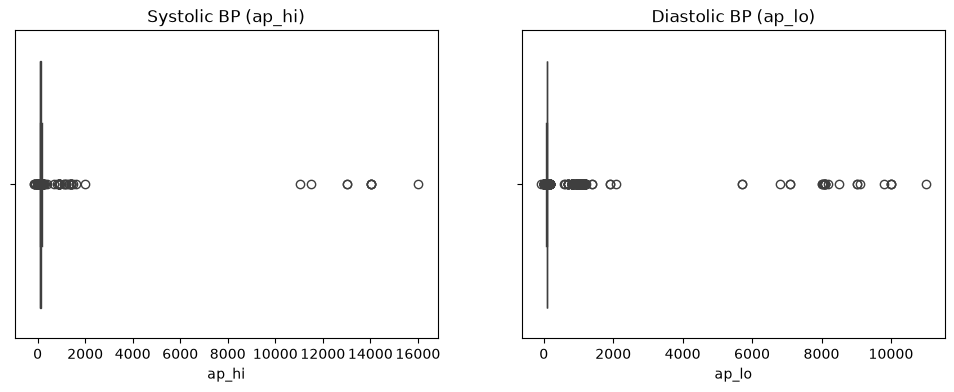

Rows remaining after outlier filtering: 68613


In [19]:
# Visualize distributions before filtering
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df['ap_hi'], ax=axes[0]).set_title('Systolic BP (ap_hi)')
sns.boxplot(x=df['ap_lo'], ax=axes[1]).set_title('Diastolic BP (ap_lo)')
plt.show()

# Filtering based on medical plausibility
# Systolic should be > diastolic and both within human limits
df = df[(df['ap_hi'] >= 80) & (df['ap_hi'] <= 250)]
df = df[(df['ap_lo'] >= 50) & (df['ap_lo'] <= 150)]
df = df[df['ap_hi'] > df['ap_lo']]

# Filter extreme height/weight that might be errors
df = df[(df['height'] >= 100) & (df['height'] <= 250)]
df = df[(df['weight'] >= 30)]

print(f"Rows remaining after outlier filtering: {len(df)}")

In [20]:
## 8. Exploratory Data Analysis (EDA)

#Visualizing how target classes differ across features like cholesterol and age.

C:\Users\HP\AppData\Local\Temp\ipykernel_18912\1947221406.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='cardio', data=df, palette='viridis')


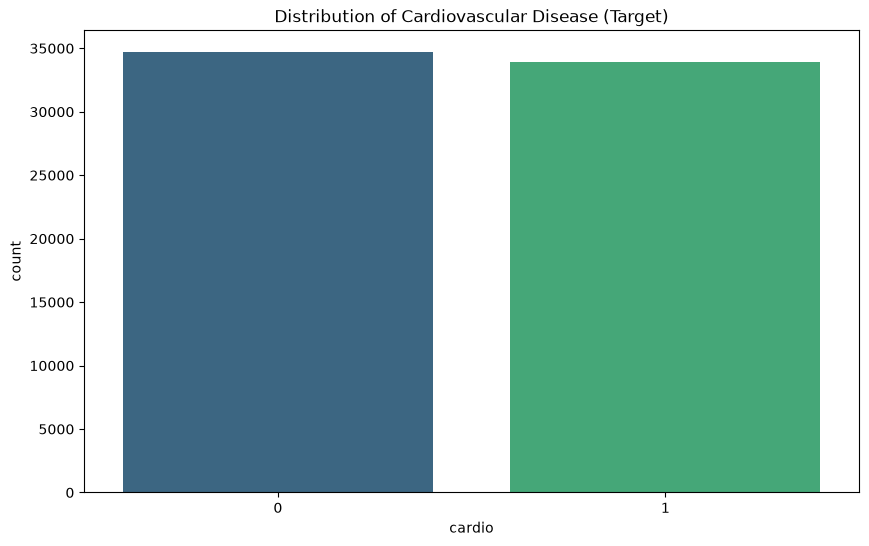

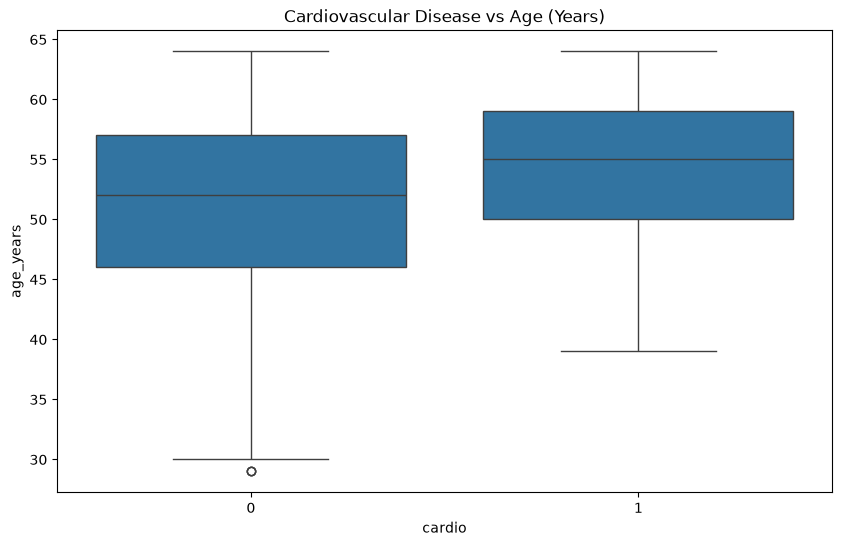

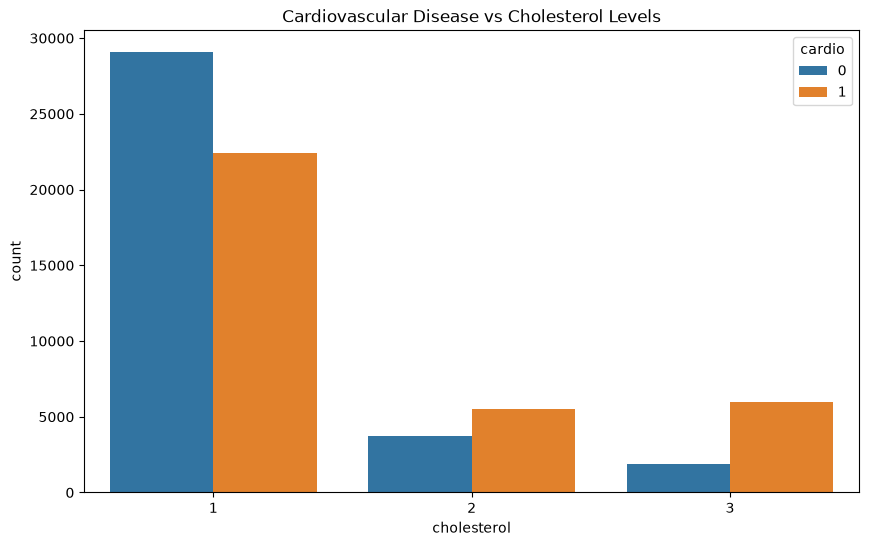

In [21]:
plt.figure(figsize=(10, 6))
sns.countplot(x='cardio', data=df, palette='viridis')
plt.title('Distribution of Cardiovascular Disease (Target)')
plt.show()

# Cardio vs Age
plt.figure(figsize=(10, 6))
sns.boxplot(x='cardio', y='age_years', data=df)
plt.title('Cardiovascular Disease vs Age (Years)')
plt.show()

# Cardio vs Cholesterol
plt.figure(figsize=(10, 6))
sns.countplot(x='cholesterol', hue='cardio', data=df)
plt.title('Cardiovascular Disease vs Cholesterol Levels')
plt.show()

In [22]:
## 9. Correlation Analysis

#Analyzing linear dependencies using a heatmap.

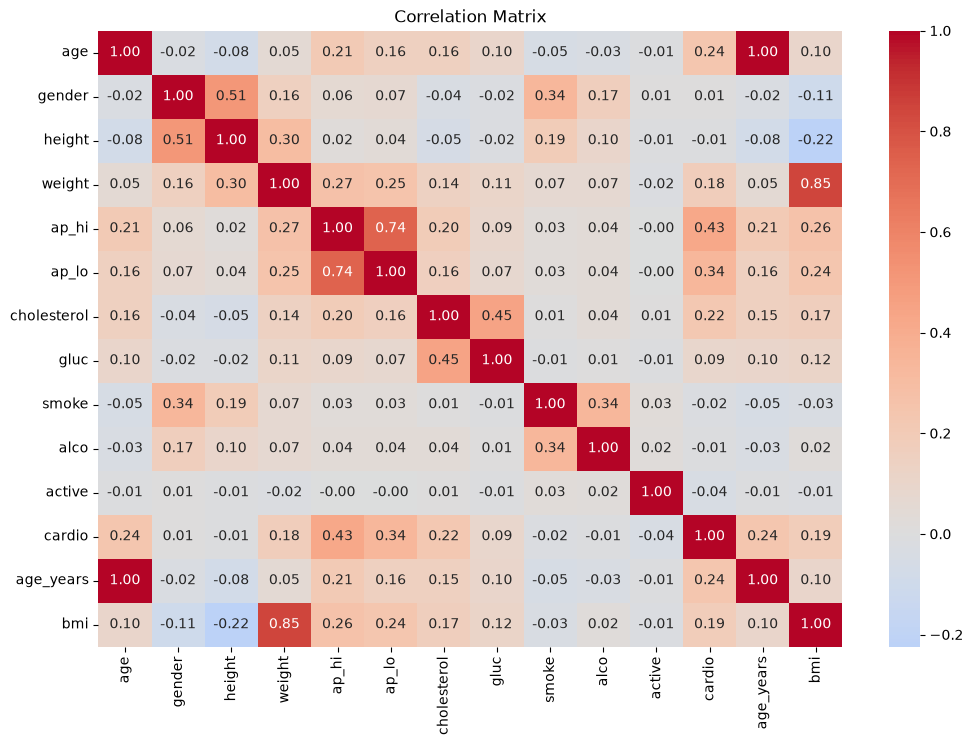

In [23]:
plt.figure(figsize=(12, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

In [24]:
## 10. Prepare Features and Target

#Splitting the data into training and test sets while maintaining target stratification.

In [25]:
X = df.drop(columns=['cardio', 'age']) # age is replaced by age_years
y = df['cardio']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (54890, 12)
Testing set shape: (13723, 12)


In [26]:
## 11. Preprocessing and Baseline

#Setting up the standard scaling and one-hot encoding pipeline.

In [27]:
numeric_features = ['height', 'weight', 'ap_hi', 'ap_lo', 'age_years', 'bmi']
categorical_features = ['cholesterol', 'gluc']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ])

# Baseline model
dummy_clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DummyClassifier(strategy='most_frequent'))
])

dummy_clf.fit(X_train, y_train)
print(f"Baseline Accuracy: {dummy_clf.score(X_test, y_test):.4f}")

Baseline Accuracy: 0.5053


In [28]:
## 12. Model Comparison and Cross-Validation

#Comparing Logistic Regression, Random Forest, and HistGradientBoosting.

In [29]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'HistGradientBoosting': HistGradientBoostingClassifier(random_state=42)
}

results = []

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    cv_results = cross_validate(
        pipeline, X_train, y_train,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring=['accuracy', 'recall', 'roc_auc']
    )

    results.append({
        'Model': name,
        'CV Accuracy': cv_results['test_accuracy'].mean(),
        'CV Recall': cv_results['test_recall'].mean(),
        'CV ROC-AUC': cv_results['test_roc_auc'].mean()
    })

results_df = pd.DataFrame(results).sort_values(by='CV ROC-AUC', ascending=False)
display(results_df)

,Model,CV Accuracy,CV Recall,CV ROC-AUC
2,HistGradientBoosting,0.734542,0.688455,0.800349
0,Logistic Regression,0.727819,0.664334,0.791352
1,Random Forest,0.700929,0.690812,0.758626


In [30]:


# 1. Create the complete pipelines (combining your preprocessor and the models)
logistic_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

gradient_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', HistGradientBoostingClassifier(random_state=42))
])

# 2. Explicitly FIT both models on the training data
logistic_pipeline.fit(X_train, y_train)
gradient_pipeline.fit(X_train, y_train)

# 3. Export the FITTED pipelines
joblib.dump(logistic_pipeline, 'logistic_model.pkl')
joblib.dump(gradient_pipeline, 'gradient_boosting_model.pkl')

print("Fitted models saved successfully.")

Fitted models saved successfully.
